In [216]:
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline

In [217]:
def f(x):
    return 3*x**2 -4*x+5

In [218]:
f(3.0)

20.0

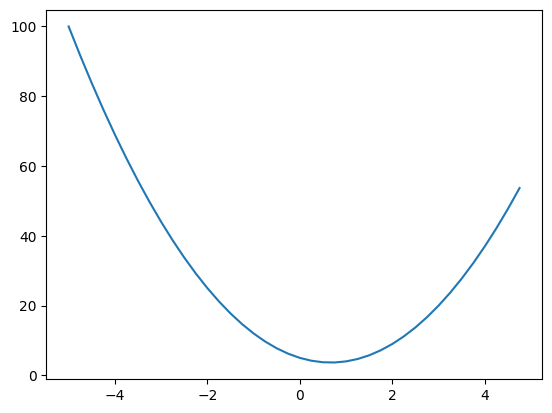

In [219]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)


In [220]:
h=0.001
x=3.0
(f(x+h)-f(x))/h

14.00300000000243

In [221]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [222]:
h=0.0001
d1=a*b+c
a+=h
d2=a*b+c
print(d1)
print(d2)
# dh/dc
print('slope',(d2-d1)/h)

4.0
3.999699999999999
slope -3.000000000010772


In [233]:
class Value:
    def __init__(self,data,_children=(),_op="",label=''):
        self.data=data
        self.grad=0.0
        self._backward=lambda:None
        self._prev=set(_children)
        self._op=_op
        self.label=label
    def __repr__(self):
        return f"Value(data={self.data},label={self.label})"

    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),_op='+')
        def _backward():
            self.grad+=1.0*out.grad # 现有out的梯度这个才能算
            other.grad+=1.0*out.grad
        # 一个节点的backward不是算自己的梯度而是自己的母节点的梯度
        out._backward=_backward 
        return out
    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other),_op='*')
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out
    def __sub__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data-other.data,_children=(self,other,),_op='-')
        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=-1.0*out.grad
        out._backward=_backward
        return out
    def __neg__(self):
        return self*-1
    def __truediv__(self, other):
        return self*other**-1
    
    def __pow__(self,other):
        assert isinstance(other,(int,float))
        out=Value(self.data**other,(self,),f'**{other}')
        def _backward():
            self.grad+=other*self.data**(other-1)*out.grad
        out._backward=_backward
        return out
    
    def __radd__(self,other):
        return self+other
    
    def __rmul__(self,other):
        return self*other
    
    def __rsub__(self,other):
        other =other if isinstance(other,Value) else Value(other)
        return other-self
    
    def __rtruediv__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        return other/self

    def tanh(self):
        n=self.data
        t=(math.exp(2*n)-1)/(math.exp(2*n)+1)
        out=Value(t,(self,),_op='tanh')
        def _backward():
            self.grad=(1-t**2)*out.grad
        out._backward=_backward
        return out
    
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self,),'exp')
        def _backward():
            self.grad=out.data*out.grad
        out._backward=_backward
        return out

    def backward(self):
        topo=[]
        visited=set()
        # 保证被运算出的节点永远在算出他的因子的后面
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        # 先让后面的节点反向传播 
        self.grad=1.0
        for node in reversed(topo):
            node._backward()        


In [224]:
a=Value(2.0,label='a')
b=Value(4.0,label='b')
-a

Value(data=-2.0,label=)

In [225]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

from graphviz import Digraph

def trace(root):
    nodes,edges=set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot=Digraph(format='svg',graph_attr={'rankdir':'LR'})
    nodes,edges=trace(root)
    for n in nodes:
        uid=str(id(n))

        dot.node(name=uid,label="{ %s|data %.4f|grad%.4f}"%(n.label,n.data,n.grad),shape='record')
        if n._op:
            dot.node(name=uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)
    
    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    return dot 

0.0


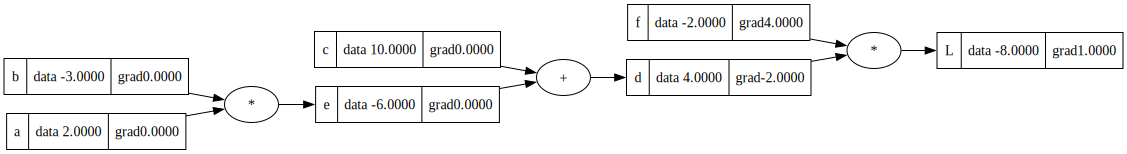

In [226]:
def lol():
    h=0.0001
    # calculate the derivative of L
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e=a*b; e.label='e'
    d = e + c
    d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f
    L.label = 'L'
    L1=L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e=a*b; e.label='e'
    d = e + c
    d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f
    L.label = 'L'
    L2=L.data

    # grad
    f.grad=4
    d.grad=-2
    L.grad=1


    
    
    print((L2-L1)/h)
    return L
L=lol()
draw_dot(L)

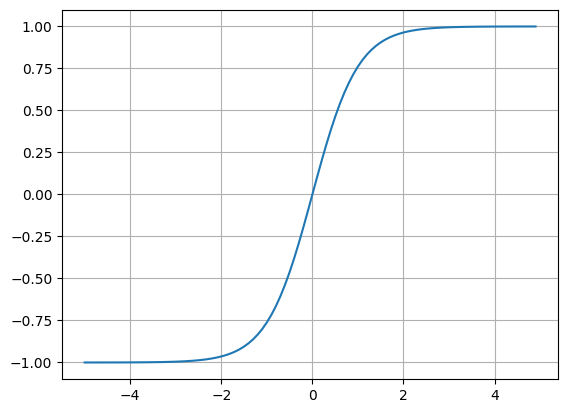

In [227]:
plt.plot(np.arange(-5,5,0.1),np.tanh(np.arange(-5,5,0.1)));plt.grid();


In [234]:
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.8813,label='b')
x1w1=x1*w1; x1w1.label='x1w1'
x2w2=x2*w2; x2w2.label='x2w2'
x1w1x2w2=x1w1+x2w2;x1w1x2w2.label='x1w1+x2w2'
n=x1w1x2w2+b;n.label='n'

#o=n.tanh()
e=(n*2).exp()
o=(e-1)/(e+1)
o.label='o'


In [229]:
o.grad=1.0
# 手动算梯度
# n.grad=1-o.data**2
# x1w1.grad=n.grad
# x2w2.grad=n.grad
# w1.grad=x1.data*x1w1.grad
# w2.grad=x2.data*x2w2.grad
# x1.grad=w1.data*x1w1.grad
# x2.grad=w2.data*x2w2.grad


In [230]:
# 写了反向传播但是manually调用

# o._backward()
# n._backward()
# x1w1x2w2._backward()
# b._backward()
# x1w1._backward()
# x2w2._backward()
# x1._backward()
# x2._backward()
# w1._backward()
# w2._backward()

上面两种方法还是手动调用的,于是我们想封装起来自动跑,但是调用_backward有个问题是,算某节点梯度的时候他的后面节点的梯度必须已知,这是由多层函数的导数相乘的法则决定的,所以我们必须先算后面的点的梯度,后算前面的,而我们需要对什么是"后"(or右)什么是"前"(or左)进行排序,也就是topo order 

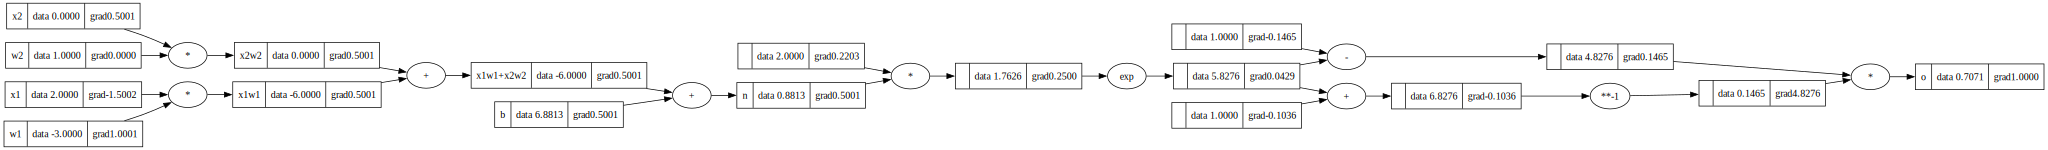

In [235]:
#封装形式的反向传播
o.backward()
draw_dot(o)

一个新的问题是:

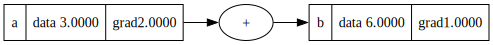

In [232]:
a=Value(3.0,label='a')
b=a+a; b.label='b'
b.backward()
draw_dot(b)

清楚注意到a.grad=1,实际上应该是2,这是因为调用的
def __add__(self,other): 其中self和other其实是同一个object,调用_backward的时候self.grad=1 other.grad=1是覆盖了上一个代码,结果a.grad一直是1,实际上应该+,故改为self.grad+=... other.grad+=...